<a href="https://colab.research.google.com/github/DDORINY/study_AI_26/blob/main/%ED%8F%89%EA%B0%80%EC%8B%9C%ED%97%98/03_AI%EA%B8%B0%EB%B0%98%EC%98%88%EC%B8%A1_%EB%B0%8F_%EB%B6%84%EC%84%9D(%EA%B9%80%EB%8F%84%ED%95%98).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **AI기반 예측 및 분석**
### **평가기준: 주제에 맞는 풀력이 가능한지 판단한다**

---

#### **[주제]**
MBC 마켓에서 이번엔 럭키백을 패션분야에 접목을 시키려고 한다.

CCTV로 판매할 제품의 객체를 판단하는 AI 모델을 만드시오

1. 패션 MNIST 데이터 셋을 활용한다.
2. target은 10개의 항목으로 되어 있다.
3. 정답 : 0티셔츠, 1바지, 2스웨터, 3드레스, 4코트, 5샌달, 6셔츠, 7스니커즈, 8가방, 9앵클부츠
---

#### **1단계 :  더미데이터 전처리**

In [10]:
import tensorflow as tf
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

# 패션 MNIST 데이터 불러오기
from tensorflow import keras
(train_input, train_target),(test_input, test_target) = keras.datasets.fashion_mnist.load_data()

#### **2단계 : 훈련데이터, 검증데이터, 테스트데이터**
(shape)

In [11]:
from sklearn.model_selection import train_test_split

# 훈련 데이터 전처리
train_scaled = train_input.reshape(-1,28,28,1) / 255.0

# 테스트 데이터 전처리
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

# 훈련/검증 데이터 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)
# 훈련 데이터, 검증데이터, 훈련타겟, 검증 타겟 → 8:2

# 데이터 크기 확인
print("훈련용세트 :",train_scaled.shape, train_target.shape)
print("검증용세트 :",val_scaled.shape, val_target.shape)
print("테스트용세트 :",test_scaled.shape, test_target.shape)

훈련용세트 : (48000, 28, 28, 1) (48000,)
검증용세트 : (12000, 28, 28, 1) (12000,)
테스트용세트 : (10000, 28, 28, 1) (10000,)


#### **3단계 : 모델용 객체 메서드 생성**
하나의 매개변수를 받아 리턴한다. *.model_fn(dense추가하면 생성)*

In [15]:
def cnn_model(a_layer = None):
    model = keras.Sequential()
    model.add(
        keras.layers.Conv2D(32,kernel_size =(3,3), activation = 'relu', padding = 'same',input_shape=(28,28,1)))
    model.add(keras.layers.MaxPool2D(2))
    model.add(
        keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
    model.add(keras.layers.MaxPool2D(2))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))

    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [16]:
model = cnn_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### **4단계 : 다중분류를 이용한 컴파일**

In [17]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#### **5단계 : 훈련**

In [18]:
history = model.fit(train_scaled,train_target, epochs =5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - accuracy: 0.7842 - loss: 0.5920
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 93s 47ms/step - accuracy: 0.8927 - loss: 0.2928
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.9103 - loss: 0.2408
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 52ms/step - accuracy: 0.9235 - loss: 0.2095
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.9334 - loss: 0.1846


#### **6단계 : 최적화 기법**

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 42ms/step - accuracy: 0.7685 - loss: 0.6324 - val_accuracy: 0.8813 - val_loss: 0.3296
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.8909 - loss: 0.3000 - val_accuracy: 0.8965 - val_loss: 0.2818
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 44ms/step - accuracy: 0.9110 - loss: 0.2470 - val_accuracy: 0.9035 - val_loss: 0.2664
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 87s 47ms/step - accuracy: 0.9228 - loss: 0.2126 - val_accuracy: 0.9097 - val_loss: 0.2481
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.9318 - loss: 0.1860 - val_accuracy: 0.9130 - val_loss: 0.2452
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9430 - loss: 0.1629 - val_accuracy: 0.9107 - val_loss: 0.2541
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9498 - loss: 0.1428 - val_accuracy: 0.9137 - val_loss: 0.2638
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.3074 -

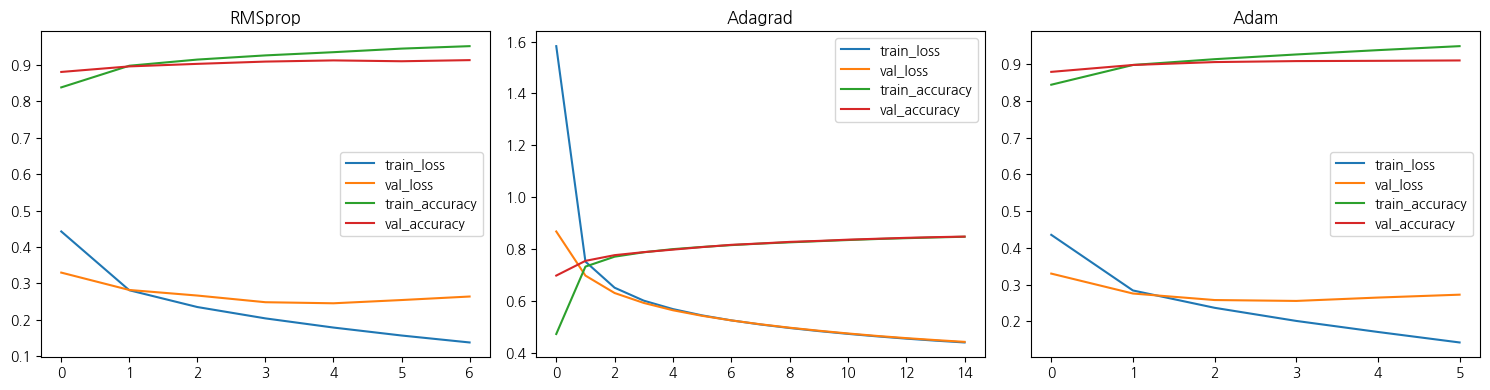

RMSprop 조기 종료 epoch: 7
Adagrad 조기 종료 없이 끝까지 학습
Adam 조기 종료 epoch: 6


In [23]:
import matplotlib.pyplot as plt

optimizers = {"RMSprop": "rmsprop","Adagrad": keras.optimizers.Adagrad(),"Adam": "adam"}

histories = {}
stopped_epochs = {}

for name, opt in optimizers.items():
    model = cnn_model()
    model.compile(optimizer=opt,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss',
        patience=2,restore_best_weights=True)

    history = model.fit(train_scaled,train_target,epochs=15,validation_data=(val_scaled, val_target),
        callbacks=[early_stopping_cb],verbose=1)

    histories[name] = history
    stopped_epochs[name] = early_stopping_cb.stopped_epoch

plt.figure(figsize=(15, 4))

for i, (name, history) in enumerate(histories.items(), 1):
    plt.subplot(1, 3, i)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(name)
    plt.legend()
plt.tight_layout()
plt.show()
for name, epoch in stopped_epochs.items():
    if epoch > 0:
        print(f"{name} 조기 종료 epoch: {epoch + 1}")
    else:
        print(f"{name} 조기 종료 없이 끝까지 학습")

In [24]:
import numpy as np

for name, history in histories.items():

    val_loss = history.history['val_loss']
    val_accuracy =history.history['val_accuracy']

    best_epoch =np.argmin(val_loss)+1

    print(f"Optimizer : {name}")
    print(f"Best Epoch : {best_epoch}")
    print(f"Best Val Loss : {np.min(val_loss):.4f}")
    print(f"Best Val Accuracy : {np.max(val_accuracy):.4f}")
    print("-" * 30)

Optimizer : RMSprop
Best Epoch : 5
Best Val Loss : 0.2452
Best Val Accuracy : 0.9137
------------------------------
Optimizer : Adagrad
Best Epoch : 15
Best Val Loss : 0.4417
Best Val Accuracy : 0.8478
------------------------------
Optimizer : Adam
Best Epoch : 4
Best Val Loss : 0.2556
Best Val Accuracy : 0.9103
------------------------------


#### **7단계 : 과대적합을 막는 기술(드롭아웃)**

In [25]:
model = cnn_model(keras.layers.Dropout(0.3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### **8단계 : 모델요약**

In [27]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### **9단계 : 훈련결과 그래프**

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7555 - loss: 0.6771 - val_accuracy: 0.8838 - val_loss: 0.3161
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.8757 - loss: 0.3460 - val_accuracy: 0.8986 - val_loss: 0.2744
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 43ms/step - accuracy: 0.8943 - loss: 0.2900 - val_accuracy: 0.9046 - val_loss: 0.2567
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 43ms/step - accuracy: 0.9037 - loss: 0.2549 - val_accuracy: 0.9110 - val_loss: 0.2352
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.9145 - loss: 0.2310 - val_accuracy: 0.9118 - val_loss: 0.2370
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.9233 - loss: 0.2061 - val_accuracy: 0.9142 - val_loss: 0.2345
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.9316 - loss: 0.1866 - val_accuracy: 0.9167 - val_loss: 0.2328
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9340 -

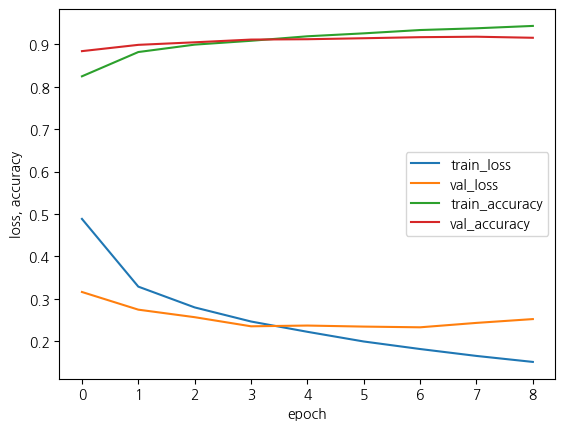

조기종료 시점 에포크 : 8
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9169 - loss: 0.2246
검증데이터 성능 확인: [0.23284050822257996, 0.9166666865348816]


In [28]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target),callbacks=[checkpoint_cb, early_stopping_cb])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()

print("조기종료 시점 에포크 :",early_stopping_cb.stopped_epoch)
print("검증데이터 성능 확인:", model.evaluate(val_scaled, val_target))

#### **10단계 : 모델 저장**

In [29]:
model.save('best-cnn-model.keras')

#### **11단계 : 모델을 불러와 테스트 점수를 확인**

In [30]:
print("테스트 데이터 점수 확인:",model.evaluate(test_scaled, test_target))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9055 - loss: 0.2807
테스트 데이터 점수 확인: [0.26514962315559387, 0.9085000157356262]


#### **12단계 : 테스트 세트에 15번 인덱스이미지**

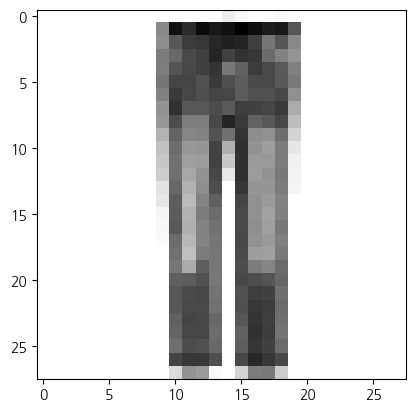

In [32]:
plt.imshow(test_scaled[15].reshape(28,28),cmap='gray_r')
plt.show()